# stratification hw

## библиотеки и функции

In [3]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import tt_ind_solve_power

In [4]:
def calculate_mean(values):
    '''Вычисляет обычное среднее'''
    return(np.mean(values))

def calculate_strat_mean(data, strata_name, gen_pop_weights, target_value):
    ''' Вычисляет стратифицированное среднее. использует веса из генеральной популяции (передаются как словарь)'''
    strats_means = data.groupby(strata_name)[target_value].mean()

    data_means_weights = pd.merge(
        pd.Series(strats_means, name='value_means'),
        pd.Series(gen_pop_weights, name='weight'),
        how='inner',
        left_index=True,
        right_index=True)

    mean_strat = (data_means_weights['weight'] * data_means_weights['value_means']).sum()
    return(mean_strat)

def calculate_strat_var(data: pd.DataFrame, strata_name: str, gen_pop_weights: dict, target_value: str):
    '''Вычисляет стратифицированную дисперсию.'''

    strat_vars = data.groupby(strata_name)[target_value].var()

    data_vars_weights = pd.merge(
        pd.Series(strat_vars, name='value_vars'),
        pd.Series(gen_pop_weights, name='weight'),
        how='inner',
        left_index=True,
        right_index=True)

    var_strat = (data_vars_weights['weight'] * data_vars_weights['value_vars']).sum()
    return (var_strat)

# Перепишем фунции для проведения t-test/ Будем использовать

def get_basic_ttest(group_A: np.array, group_B: np.array):
    '''Проверяет гипотезу о равенстве средних для обычного среднего.
    return - t_stat, p_value.'''

    t_stat, p_value = stats.ttest_ind(group_A, group_B)
    inference = {'t_stat': t_stat, 'p_value':p_value}
    return(inference)


def get_strat_ttest(df_A: pd.DataFrame, df_B: pd.DataFrame, strata_name: str, target_value: str, gen_pop_weights: dict):
    """Проверяет гипотезу о равенстве средних для стратифицированного среднего и стратифицировнной дисперсии.

    return - pvalue.
    """
    mean_strat_A =  calculate_strat_mean(df_A, strata_name, gen_pop_weights, target_value)
    mean_strat_B =  calculate_strat_mean(df_B, strata_name, gen_pop_weights, target_value)

    var_strat_A = calculate_strat_var(df_A, strata_name, gen_pop_weights, target_value)
    var_strat_B = calculate_strat_var(df_B, strata_name, gen_pop_weights, target_value)

    delta_mean_strat = mean_strat_A - mean_strat_B
    std_mean_strat = np.sqrt(var_strat_A / len(df_A) + var_strat_B / len(df_B))
    t_stat_strat = delta_mean_strat / std_mean_strat
    p_value = 2 * (1 - stats.norm.cdf(np.abs(t_stat_strat)))

    inference = {'t_stat': t_stat_strat, 'p_value':p_value}
    return (inference)

# Выбрать страту и провести тест

Вы аналитик в команде монетизации классифайда. Ваша команда провела тест с экранами платных услуг в монетизации. Основная гипотеза заключалась в том, что мы сможем увеличить ARPU на +3.5 рубля.
У нас есть данные по продавцам авто, участвующим в тесте stratification_homework_2.csv 
Будем анализировать этот тест.

Схема данных
•	ARPU: целевая метрика в тесте
•	is_capital: продавец авто из столицы (capital) или из регионов (region)
•	is_pro: профессиональный или нет продавец (1 — профи, 0 — простой)
•	group: группа в А/Б-тесте (1 — тестовая, 0 — контрольная)

## load data

In [6]:
df_data = pd.read_csv('2 stratification_homework_2.csv')

In [7]:
df_data.info()
df_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9700 entries, 0 to 9699
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ARPU        9700 non-null   float64
 1   is_capital  9700 non-null   object 
 2   is_pro      9700 non-null   int64  
 3   group       9700 non-null   int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 303.3+ KB


,ARPU,is_capital,is_pro,group
0,250.5,region,1,1
1,182.0,capital,0,1
2,75.0,region,0,0
3,532.5,capital,1,0
4,88.0,region,0,1


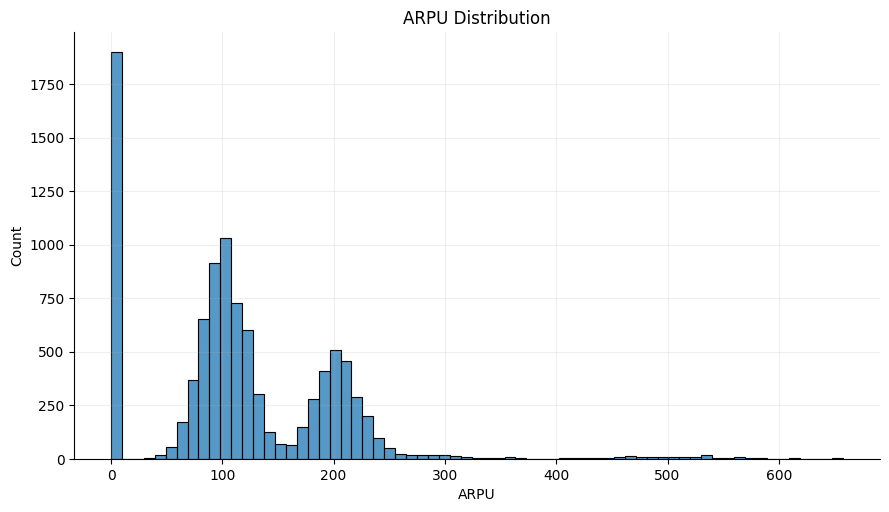

In [65]:
sns.displot(df_data.ARPU, aspect=1.8)
plt.grid(True, alpha=0.2)
plt.title('ARPU Distribution')
plt.show()

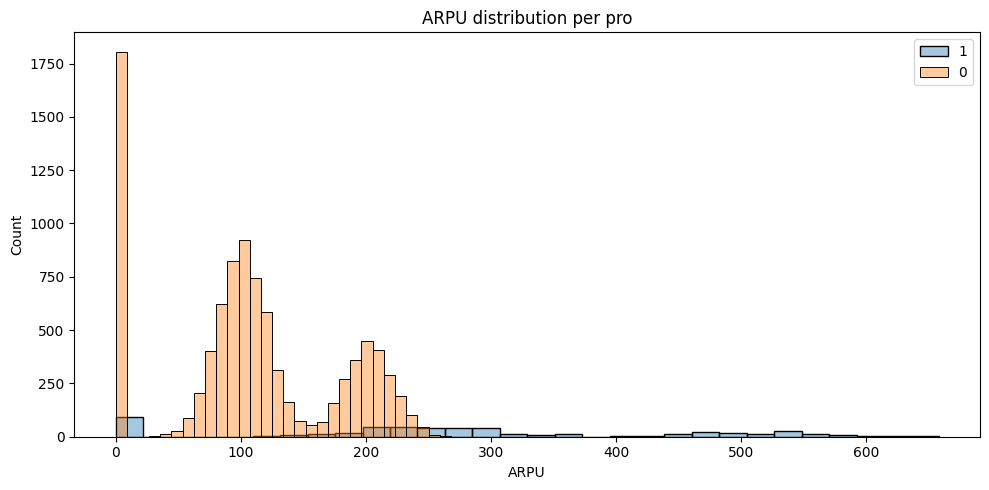

In [78]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df_data.loc[df_data.is_pro == 1, 'ARPU'], ax=ax, stat='count', bins=30, alpha=0.4, label='1')
sns.histplot(df_data.loc[df_data.is_pro == 0, 'ARPU'], ax=ax, stat='count', bins=30, alpha=0.4, label='0')

ax.set_title('ARPU distribution per pro')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df_data.loc[df_data.is_capital == 'capital', 'ARPU'], ax=ax, stat='count', bins=30, alpha=0.4, label='capital')
sns.histplot(df_data.loc[df_data.is_capital == 'region', 'ARPU'], ax=ax, stat='count', bins=30, alpha=0.4, label='region')

ax.set_title('ARPU distribution per regions')
ax.legend()
plt.tight_layout()
plt.show()

## Задание 1. Проведите простой t-test для нестратифицированных данных

In [26]:
get_basic_ttest(
    df_data.loc[df_data.group==0, 'ARPU'],
    df_data.loc[df_data.group==1, 'ARPU']
    )

{'t_stat': np.float64(-1.8461206634143887),
 'p_value': np.float64(0.06490514155787333)}

## Задание 2. Найдите оптимальную страту для разбиения

In [63]:
# df_data.columns
strats = ['is_capital', 'is_pro']
value = 'ARPU'
arpu_var = df_data.ARPU.var()
starts_result = {}
print(f"Общая дисперсия ARPU - {arpu_var:.3f}")

for strata in strats:
    # calc general weights
    gen_pop_weights = df_data.loc[:,strata].value_counts(normalize=True).to_dict()
    # get new variance
    strat_var = calculate_strat_var(
        data=df_data,
        strata_name=strata,
        gen_pop_weights=gen_pop_weights,
        target_value=value
    )
    # save strat result
    starts_result.update({strata: strat_var/arpu_var})
    
    print(f"  >> Stratification variance for '{strata}' is {strat_var:.3f} and it's {strat_var/arpu_var-1:.1%}")

print()
print(f"Best strata is: {[(k, round(v-1, 3)) for k,v in sorted(starts_result.items(), key=lambda tpl: tpl[1])][0]}")

Общая дисперсия ARPU - 7480.429
  >> Stratification variance for 'is_capital' is 5789.948 and it's -22.6%
  >> Stratification variance for 'is_pro' is 6193.935 and it's -17.2%

Best strata is: ('is_capital', np.float64(-0.226))


## Задание 3. Проведите стратифицированный t-test по наилучшей страте полученной в задании 2

In [83]:
gen_pop_weights = df_data.loc[:, 'is_capital'].value_counts(normalize=True).to_dict()

get_strat_ttest(
    df_A=df_data.loc[df_data.is_capital=='capital'],
    df_B=df_data.loc[df_data.is_capital=='region'],
    strata_name='is_capital',
    target_value='ARPU',
    gen_pop_weights=gen_pop_weights
)

{'t_stat': np.float64(-2.3546512663465564),
 'p_value': np.float64(0.01854009604310014)}

## Задание 4. Найдите размер выборки

Взяв за основу контрольную группу (group = 0) найдите размер выборки, который нужен был бы, чтобы найти абсолютный MDE = 3 при обычном и стратифицированном критерии.

In [103]:
# укажем параметры распределения и размер эффекта
alpha = 0.05
beta = 0.2
std = 50
mean = 100
power = 1 - beta
lift = 0.05 # Хотим увидеть 5% изменение в метрику. Tоже самое что чувствительность MDE
effect_size = mean * lift / std # Абсолютный эффект делим на стандартное отклонение

print('Effect size =', effect_size)
print('Mean lift =', mean*lift)

# найдем размер выборки
sample_size = int(tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, nobs1=None, ratio=1))
print('Sample size =', sample_size)

Effect size = 0.1
Mean lift = 5.0
Sample size = 1570


In [116]:
alpha = 0.05
beta = 0.2
power = 1 - beta
MDE_abs = 3

control_value = df_data.loc[df_data.group==0, 'ARPU']

control_mean = control_value.mean()
control_var = control_value.std(ddof=1)
effect_size = (MDE_abs) / control_var

print(f"{control_mean=:.2f}")
print(f"{control_var=:.2f}")
print(f"{MDE_abs=:.2f}")
print(f"{effect_size=:.2f}")

sample_size = tt_ind_solve_power(
    effect_size=effect_size,
    nobs1=None,
    alpha=alpha,
    power=power,
    ratio=1.0,
    alternative='two-sided',
)

print('\n',"Рассчет размера выборки без использования стратификации.", sep='')
print(f"{sample_size=:.0f}")

control_mean=114.83
control_var=87.25
MDE_abs=3.00
effect_size=0.03

Рассчет размера выборки без использования стратификации.
sample_size=13277


In [119]:
gen_pop_weights = df_data.loc[:, 'is_capital'].value_counts(normalize=True).to_dict()

strat_var = calculate_strat_var(
        data=df_data,
        strata_name='is_capital',
        gen_pop_weights=gen_pop_weights,
        target_value='ARPU'
    )
effect_size = MDE_abs / np.sqrt(strat_var)

print(f"{strat_var=:.2f}")
print(f"{effect_size=:.2f}")

start_sample_size = tt_ind_solve_power(
    effect_size=effect_size,
    nobs1=None,
    alpha=alpha,
    power=power,
    ratio=1.0,
    alternative='two-sided',
)

print('\n',"Рассчет размера выборки с использованием стратификации по страте 'is_capital'.", sep='')
print(f"{start_sample_size=:.0f} ({start_sample_size/sample_size-1:.1%} to base sample size)")

strat_var=5789.95
effect_size=0.04

Рассчет размера выборки с использованием стратификации по страте 'is_capital'.
start_sample_size=10100 (-23.9% to base sample size)
